In [20]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [21]:
accelerometer_features = pd.read_csv('../Datasets/ExtractedFeatures/accelerometer_features.csv')
accelerometer_features.head(2)

,mean_x,mean_y,mean_z,std_x,std_y,std_z,var_x,var_y,var_z,sum_x,...,dominant_freq_x,spectral_energy_x,spectral_entropy_x,dominant_freq_y,spectral_energy_y,spectral_entropy_y,dominant_freq_z,spectral_energy_z,spectral_entropy_z,surface_id
0,0.112089,-0.020208,-0.146214,1.393633,0.848164,1.965022,1.942212,0.719382,3.861311,114.779246,...,16,1.030453e+06,5.720418,16,376802.558974,5.898189,115,2.044868e+06,5.844206,9
1,0.001868,0.004800,-0.015046,0.109489,0.108055,0.139761,0.011988,0.011676,0.019533,1.912782,...,13,6.281730e+03,5.952098,142,6139.640975,5.933340,97,1.046684e+04,6.022899,9


In [22]:
# Separate features and target
X = accelerometer_features.drop('surface_id', axis=1)
y = accelerometer_features['surface_id']
y = y - 2  # Convert to 0-based labels if needed

print(y.value_counts())

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (important for MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


surface_id
4    488
6    482
5    472
0    351
1    326
3    326
2    173
7     79
8     78
Name: count, dtype: int64


In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score


# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans — n_clusters matches number of surface types
n_clusters = len(np.unique(y))

kmeans     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Evaluation
ari       = adjusted_rand_score(y, cluster_labels)
nmi       = normalized_mutual_info_score(y, cluster_labels)
silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Clusters found:       {n_clusters}")
print(f"Adjusted Rand Index:  {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"NMI Score:            {nmi:.4f}  (1.0 = perfect)")
print(f"Silhouette Score:     {silhouette:.4f}  (1.0 = perfect, <0 = bad)")





Clusters found:       9
Adjusted Rand Index:  0.2833  (1.0 = perfect, 0 = random)
NMI Score:            0.4420  (1.0 = perfect)
Silhouette Score:     0.1572  (1.0 = perfect, <0 = bad)


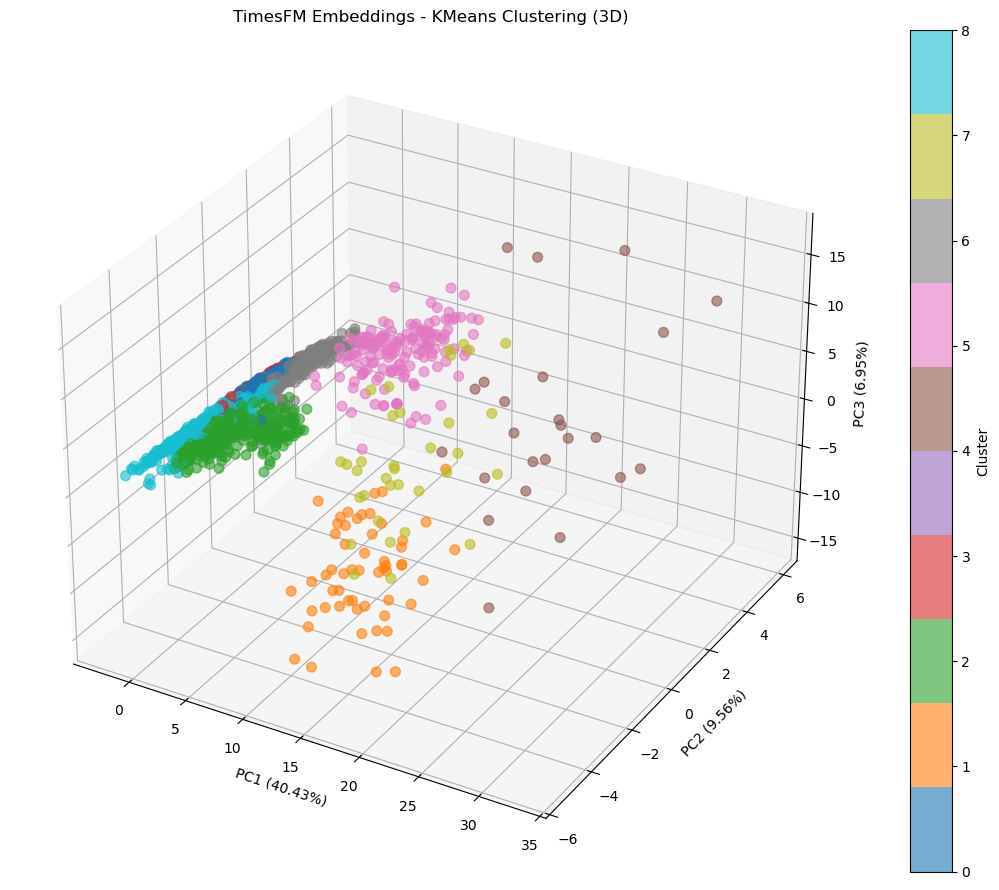

In [24]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce embeddings to 3D using PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                     c=cluster_labels, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax.set_title('TimesFM Embeddings - KMeans Clustering (3D)')
plt.tight_layout()
plt.show()

In [25]:
from collections import Counter

# Count samples per cluster
cluster_counts = Counter(cluster_labels)
print("Samples per cluster:")
for cluster_id in sorted(cluster_counts.keys()):
    print(f"  Cluster {cluster_id}: {cluster_counts[cluster_id]} samples")

# Map clusters to true surface classes
cluster_to_class = {}
for cluster_id in range(n_clusters):
    mask = cluster_labels == cluster_id
    true_classes = y[mask]
    most_common_class = Counter(true_classes).most_common(1)[0][0]
    cluster_to_class[cluster_id] = most_common_class

print("\nCluster to Surface Class mapping:")
for cluster_id, surface_class in sorted(cluster_to_class.items()):
    print(f"  Cluster {cluster_id} -> Surface Class {surface_class + 2}")

Samples per cluster:
  Cluster 0: 452 samples
  Cluster 1: 55 samples
  Cluster 2: 375 samples
  Cluster 3: 590 samples
  Cluster 4: 24 samples
  Cluster 5: 155 samples
  Cluster 6: 522 samples
  Cluster 7: 34 samples
  Cluster 8: 568 samples

Cluster to Surface Class mapping:
  Cluster 0 -> Surface Class 2
  Cluster 1 -> Surface Class 9
  Cluster 2 -> Surface Class 8
  Cluster 3 -> Surface Class 8
  Cluster 4 -> Surface Class 9
  Cluster 5 -> Surface Class 5
  Cluster 6 -> Surface Class 3
  Cluster 7 -> Surface Class 10
  Cluster 8 -> Surface Class 6
